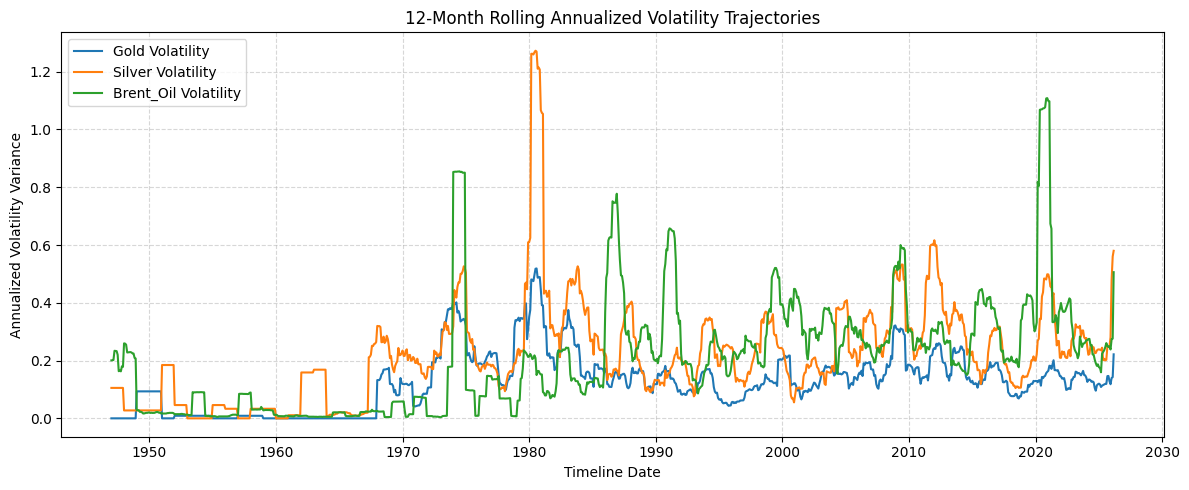

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

def find_kaggle_file(filename):
    input_dir = '/kaggle/input'
    for root, dirs, files in os.walk(input_dir):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find {filename}")

gold_df = pd.read_csv(find_kaggle_file('Gold 100years.csv'), parse_dates=['Date']).set_index('Date')
silver_df = pd.read_csv(find_kaggle_file('silver 100 years.csv'), parse_dates=['Date']).set_index('Date')
brent_df = pd.read_csv(find_kaggle_file('Brent Oil.csv'), parse_dates=['Date']).set_index('Date')

gold_df = gold_df.rename(columns={'Value': 'Gold'})
silver_df = silver_df.rename(columns={'Value': 'Silver'})
brent_df = brent_df.rename(columns={'Value': 'Brent_Oil'})

commodities = gold_df.join([silver_df, brent_df], how='inner')

log_returns = np.log(commodities / commodities.shift(1)).dropna()
rolling_vol = log_returns.rolling(window=12).std() * np.sqrt(12)
rolling_vol_cleaned = rolling_vol.dropna()


with PdfPages('task1_volatility_trajectories.pdf') as pdf:
    plt.figure(figsize=(12, 5))
    for col in rolling_vol_cleaned.columns:
        plt.plot(rolling_vol_cleaned.index, rolling_vol_cleaned[col], label=f'{col} Volatility')
    plt.title('12-Month Rolling Annualized Volatility Trajectories')
    plt.xlabel('Timeline Date')
    plt.ylabel('Annualized Volatility Variance')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    pdf.savefig() 
    plt.show()
    plt.close()